# The DNA of World Cup Squads: Unsupervised Team Similarity & Silhouette Clustering



Squad construction in international football reveals a team's underlying sporting identity. Rather than predicting match outcomes, this notebook explores how the 48 squads of the 2026 FIFA World Cup are assembled.



We engineer custom cohesion features—such as domestic league reliance and club-level synergy—to build a multi-dimensional squad profile. Using pairwise distance metrics, hierarchical tree modeling, and silhouette-score optimized K-Means clustering, we identify team similarity patterns and distinct squad archetypes.


In [23]:
import os

import re

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

from scipy.spatial.distance import pdist, squareform



# Set style for publication-quality charts

sns.set_theme(style="whitegrid")

plt.rcParams.update({

    'figure.figsize': (10, 6),

    'axes.titlesize': 14,

    'axes.labelsize': 12,

    'xtick.labelsize': 10,

    'ytick.labelsize': 10

})


## Data Loading & Robust Path Resolution



We load the dataset using `utf-8-sig` encoding to handle potential Byte Order Marks (BOM). The path resolution dynamically checks for local execution or the standard Kaggle input directory.


In [24]:
file_path = 'SquadLists.csv'

if not os.path.exists(file_path):

    file_path = '/kaggle/input/datasets/cabcon/fifa-world-cup-2026-squad-lists-all-48-teams/SquadLists.csv'



df = pd.read_csv(file_path, encoding='utf-8-sig')

print(f"Loaded dataset with {df.shape[0]} players and {df.shape[1]} features.")


Loaded dataset with 1248 players and 13 features.


## Feature Engineering: Player Age Profiles



Date of birth is parsed to calculate player ages. We use June 1, 2026, as the reference date representing the start of the 2026 FIFA World Cup tournament.


In [25]:
df['DOB'] = pd.to_datetime(df['DOB'], format='%d/%m/%Y', errors='coerce')

ref_date = pd.Timestamp('2026-06-01')

df['Age'] = (ref_date - df['DOB']).dt.days / 365.25

df[['Player Name', 'DOB', 'Age']].head()


,Player Name,DOB,Age
0,MASTIL Melvin,2000-02-19,26.280630
1,MANDI Aissa,1991-10-22,34.609172
2,ABADA Achref,1999-06-15,26.962355
3,TOUGAI Mohamed Amine,2000-01-22,26.357290
4,BELAID Zineddine,1999-03-20,27.200548


## Feature Engineering: Club and League Country Separation



The `Club` column contains the team name and its country code in parentheses (e.g. "Lille OSC (FRA)"). We separate these using regular expressions to evaluate club geography and league demographics.


In [26]:
def extract_country(club_str):

    if pd.isna(club_str):

        return None

    match = re.search(r'\(([^)]+)\)$', str(club_str))

    return match.group(1).strip() if match else None



df['Club_Country'] = df['Club'].apply(extract_country)

df['Club_Name'] = df['Club'].apply(lambda x: re.sub(r'\s*\([^)]+\)$', '', str(x)).strip() if pd.notna(x) else None)

df[['Player Name', 'Club', 'Club_Name', 'Club_Country']].head()


,Player Name,Club,Club_Name,Club_Country
0,MASTIL Melvin,FC Stade Nyonnais (SUI),FC Stade Nyonnais,SUI
1,MANDI Aissa,Lille OSC (FRA),Lille OSC,FRA
2,ABADA Achref,USM Alger (ALG),USM Alger,ALG
3,TOUGAI Mohamed Amine,Espérance De Tunisie (TUN),Espérance De Tunisie,TUN
4,BELAID Zineddine,JS Kabylie (ALG),JS Kabylie,ALG


## Designing Cohesion Metrics: Domestic Reliance & Club Synergy



To model squad familiarity, we define two metrics:

1. **Domestic Reliance Index (DRI)**: The proportion of players in a national squad who play in their home domestic league.

2. **Club Synergy Index (CSI)**: Calculated as `(squad_size - unique_clubs) / (squad_size - 1)`. A value of 1.0 means all players come from the same club, while 0.0 means every player comes from a different club.


In [27]:
df['Is_Domestic'] = df['Team Code'] == df['Club_Country']



def compute_csi(clubs):

    n = len(clubs)

    if n <= 1:

        return 0.0

    return (n - clubs.nunique()) / (n - 1)



print("Metrics initialized. Sample player domestic indicators:")

df[['Player Name', 'Team Code', 'Club_Country', 'Is_Domestic']].head()


Metrics initialized. Sample player domestic indicators:


,Player Name,Team Code,Club_Country,Is_Domestic
0,MASTIL Melvin,ALG,SUI,False
1,MANDI Aissa,ALG,FRA,False
2,ABADA Achref,ALG,ALG,True
3,TOUGAI Mohamed Amine,ALG,TUN,False
4,BELAID Zineddine,ALG,ALG,True


## Aggregating Player Profiles into National Squad Identities



We compress player-level features into a single matrix representing the collective profile of each national team. The features span age, height, international experience, goalscoring power, league diversity, and our cohesion indexes.


In [28]:
team_stats = df.groupby('Team').agg(

    Average_Age=('Age', 'mean'),

    Average_Height=('Height (cm)', 'mean'),

    Average_Caps=('Caps', 'mean'),

    Average_Goals=('Goals', 'mean'),

    Total_Goals=('Goals', 'sum'),

    Domestic_Reliance=('Is_Domestic', 'mean'),

    Club_Synergy=('Club_Name', compute_csi),

    League_Diversity=('Club_Country', 'nunique')

).reset_index()



team_stats.head()


,Team,Average_Age,Average_Height,Average_Caps,Average_Goals,Total_Goals,Domestic_Reliance,Club_Synergy,League_Diversity
0,Algeria,26.829990,182.653846,29.884615,4.653846,121,0.115385,0.08,13
1,Argentina,29.090823,179.576923,48.115385,8.576923,223,0.076923,0.28,9
2,Australia,27.332070,183.576923,28.884615,2.884615,75,0.192308,0.16,13
3,Austria,28.584110,184.961538,38.615385,5.730769,149,0.115385,0.16,10
4,Belgium,27.587111,185.807692,41.730769,8.230769,214,0.115385,0.32,8


## Squad Landscape: International Experience vs. Age Profile



We examine the trade-off between squad aging and international experience. This visualization checks if highly capped squads are exclusively older, or if some nations possess young but seasoned cohorts.


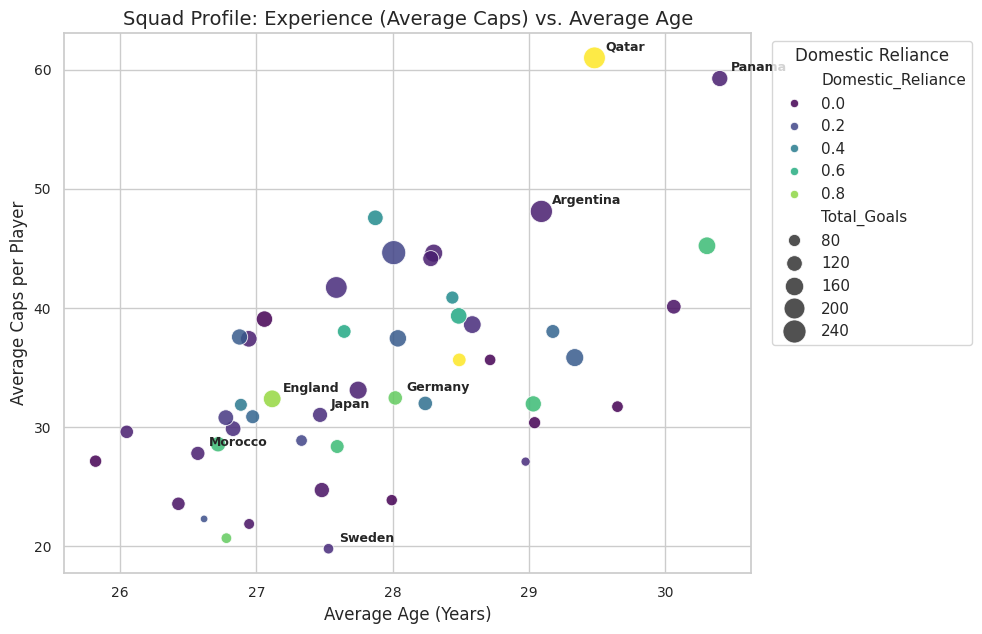

In [29]:
plt.figure(figsize=(10, 6.5))

sns.scatterplot(

    data=team_stats,

    x='Average_Age',

    y='Average_Caps',

    size='Total_Goals',

    sizes=(30, 300),

    hue='Domestic_Reliance',

    palette='viridis',

    alpha=0.85

)



# Annotate subset of teams across different quadrants

label_teams = ['Qatar', 'Panama', 'Argentina', 'Sweden', 'Morocco', 'Germany', 'England', 'Japan']

for _, row in team_stats.iterrows():

    if row['Team'] in label_teams:

        plt.annotate(

            row['Team'], 

            (row['Average_Age'] + 0.08, row['Average_Caps'] + 0.6),

            fontsize=9, 

            weight='semibold'

        )



plt.title('Squad Profile: Experience (Average Caps) vs. Average Age')

plt.xlabel('Average Age (Years)')

plt.ylabel('Average Caps per Player')

plt.legend(title='Domestic Reliance', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

plt.show()


### Insight: Age & Experience Dispersal



A clear correlation exists between age and caps, but distinct outliers emerge. Some squads combine high experience with relatively low average age, while others showcase older rosters with surprisingly low international caps, reflecting differing selection policies.


## Squad Cohesion: Domestic Reliance vs. Club Synergy



This plot contrasts league localization (DRI) against team-level clustering (CSI). It isolates squads composed of domestic league block-selections from those whose players are distributed across a wide range of foreign leagues.


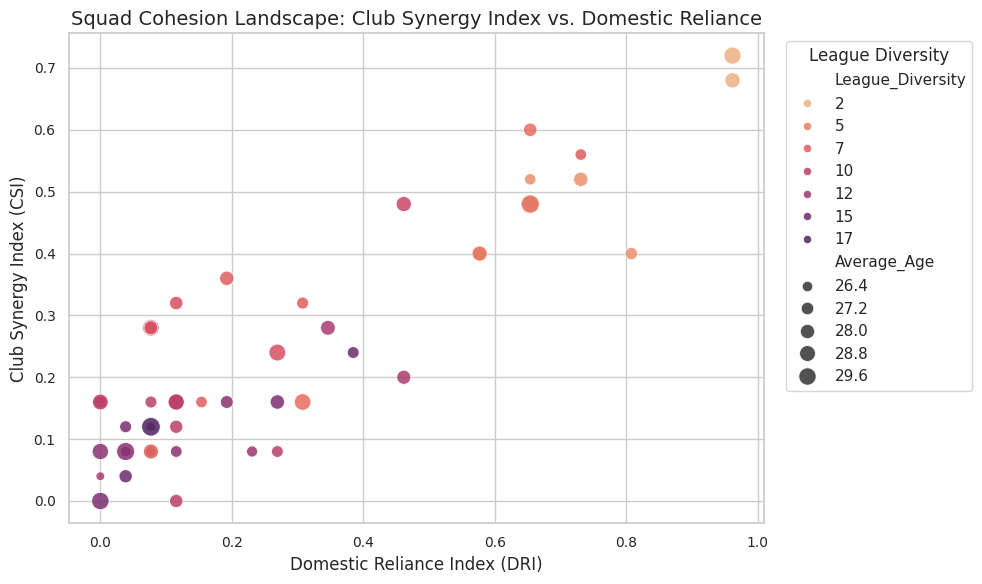

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(

    data=team_stats,

    x='Domestic_Reliance',

    y='Club_Synergy',

    hue='League_Diversity',

    palette='flare',

    size='Average_Age',

    sizes=(40, 180),

    alpha=0.85

)

plt.title('Squad Cohesion Landscape: Club Synergy Index vs. Domestic Reliance')

plt.xlabel('Domestic Reliance Index (DRI)')

plt.ylabel('Club Synergy Index (CSI)')

plt.legend(title='League Diversity', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

plt.show()


### Insight: Cohesion Archetypes



Nations divide into distinct structural quadrants. High-synergy squads rely on clusters of players playing together at the club level, whereas other squads feature zero domestic reliance and high club dispersion, requiring different approaches to tactical preparation.


## Quantitative Team Similarity & Distance Analysis



To measure squad identity similarity, we standardize the team features and calculate their pairwise Euclidean distance. This provides a rigorous mathematical basis for finding squad look-alikes.


In [31]:
features = ['Average_Age', 'Average_Height', 'Average_Caps', 'Average_Goals', 'Domestic_Reliance', 'Club_Synergy', 'League_Diversity']

scaler = StandardScaler()

scaled_features = scaler.fit_transform(team_stats[features])

scaled_df = pd.DataFrame(scaled_features, columns=features, index=team_stats['Team'])



dist_matrix = squareform(pdist(scaled_df, metric='euclidean'))

dist_df = pd.DataFrame(dist_matrix, index=team_stats['Team'], columns=team_stats['Team'])



# Extract pairwise distances

pairs = []

for i in range(len(team_stats)):

    for j in range(i + 1, len(team_stats)):

        pairs.append({

            'Team A': team_stats['Team'].iloc[i],

            'Team B': team_stats['Team'].iloc[j],

            'Distance': dist_df.iloc[i, j]

        })

pairs_df = pd.DataFrame(pairs).sort_values('Distance')



print("Top 10 Most Similar Team Pairs:")

print(pairs_df.head(10).to_string(index=False))

print("\nTop 10 Most Dissimilar Team Pairs:")

print(pairs_df.tail(10).to_string(index=False))


Top 10 Most Similar Team Pairs:
       Team A      Team B  Distance
      Algeria     Morocco  0.641108
   Cabo Verde    Congo DR  0.791018
      Croatia Switzerland  0.877827
Côte D'Ivoire     Morocco  0.966807
       Canada         USA  0.966814
      Czechia     Germany  0.999314
       Canada     Senegal  1.007963
      Austria     Croatia  1.028330
       Canada       Japan  1.057635
      Ecuador     Morocco  1.068871

Top 10 Most Dissimilar Team Pairs:
                Team A       Team B  Distance
               Curaçao        Qatar  7.606444
Bosnia And Herzegovina Saudi Arabia  7.622524
               Morocco        Qatar  7.722172
            Cabo Verde        Qatar  7.788083
                 Haiti        Qatar  8.012764
         Côte D'Ivoire        Qatar  8.334149
                 Ghana        Qatar  8.443622
                 Qatar      Tunisia  8.595978
                 Qatar       Sweden  8.718422
Bosnia And Herzegovina        Qatar  9.172291


## Hierarchical Clustering: The Squad Similarity Tree



We construct a dendrogram using Ward's linkage method. This hierarchical tree shows how squads group together at different distance thresholds, illustrating natural clusters of squad organization.


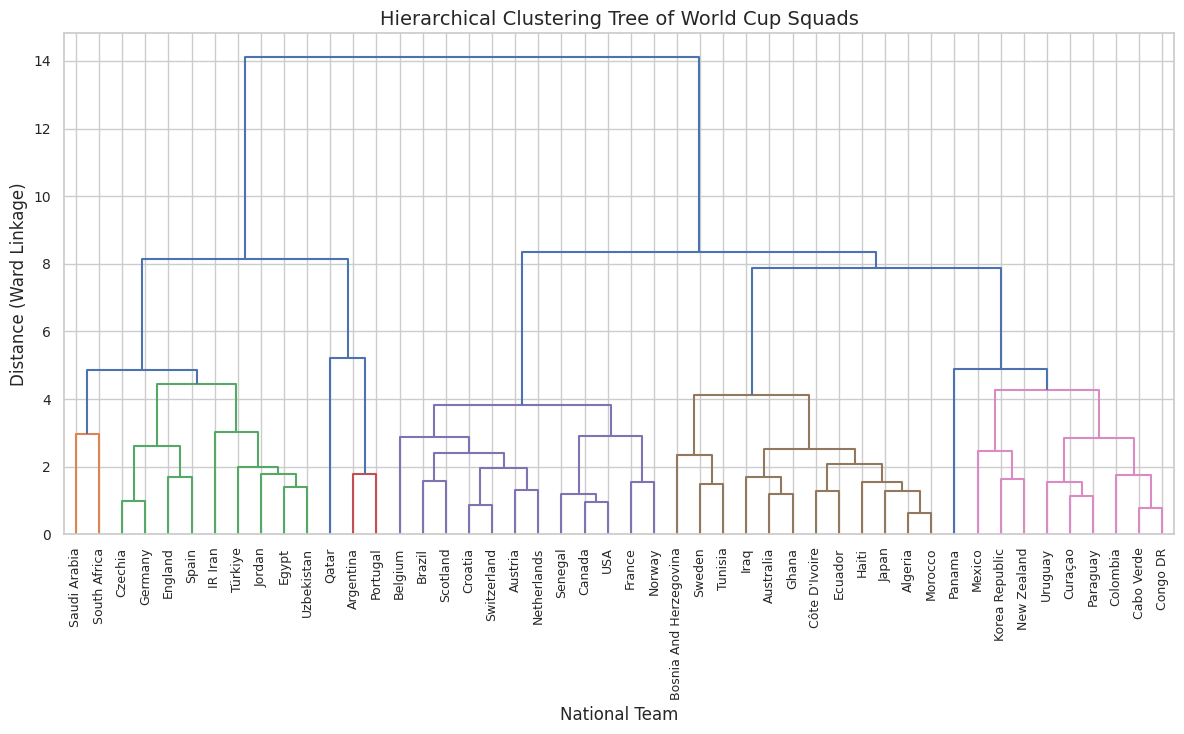

In [32]:
linked = linkage(scaled_df, method='ward')



plt.figure(figsize=(12, 7.5))

dendrogram(

    linked,

    labels=team_stats['Team'].values,

    leaf_rotation=90,

    leaf_font_size=9,

    color_threshold=4.5

)

plt.title('Hierarchical Clustering Tree of World Cup Squads')

plt.xlabel('National Team')

plt.ylabel('Distance (Ward Linkage)')

plt.tight_layout()

plt.show()


## Unsupervised Clustering: Silhouette-Score Optimal K Selection



Instead of choosing a cluster count in advance, we compute the silhouette score for K-means models across 2 to 8 clusters. The K value that maximizes this metric is selected to ensure natural cluster partitions.


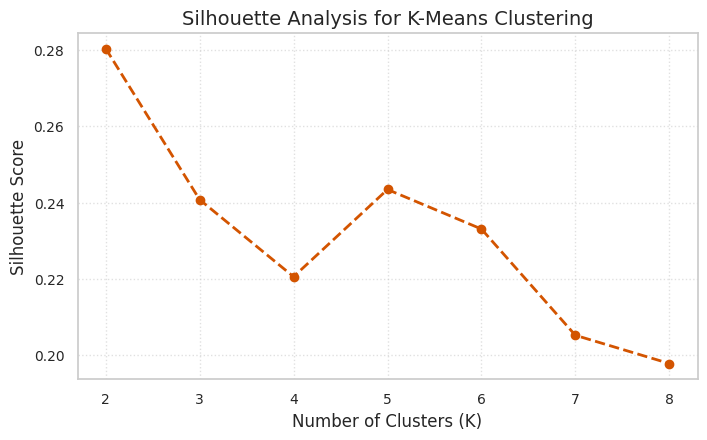

The mathematical optimal number of clusters is K = 2 (Silhouette Score: 0.2804)


In [33]:
K_range = range(2, 9)

silhouette_scores = []



for k in K_range:

    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = km.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)

    silhouette_scores.append(score)



plt.figure(figsize=(8, 4.5))

plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='#d35400', linewidth=2)

plt.title('Silhouette Analysis for K-Means Clustering')

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Silhouette Score')

plt.xticks(K_range)

plt.grid(True, linestyle=':', alpha=0.6)

plt.show()



optimal_k = K_range[np.argmax(silhouette_scores)]

print(f"The mathematical optimal number of clusters is K = {optimal_k} (Silhouette Score: {max(silhouette_scores):.4f})")


## Fitting the K-Means Model



We fit K-means using the optimal cluster count identified by the silhouette analysis, partitioning the squads based on their structural characteristics.


In [34]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

team_stats['Cluster'] = kmeans.fit_predict(scaled_features)

print(f"Teams partitioned successfully into {optimal_k} clusters.")


Teams partitioned successfully into 2 clusters.


## Dimension Reduction & Cluster Visualization (PCA)



We apply Principal Component Analysis (PCA) to project the 7-dimensional feature space into a 2D plane, mapping squad configurations and their respective cluster groups visually.


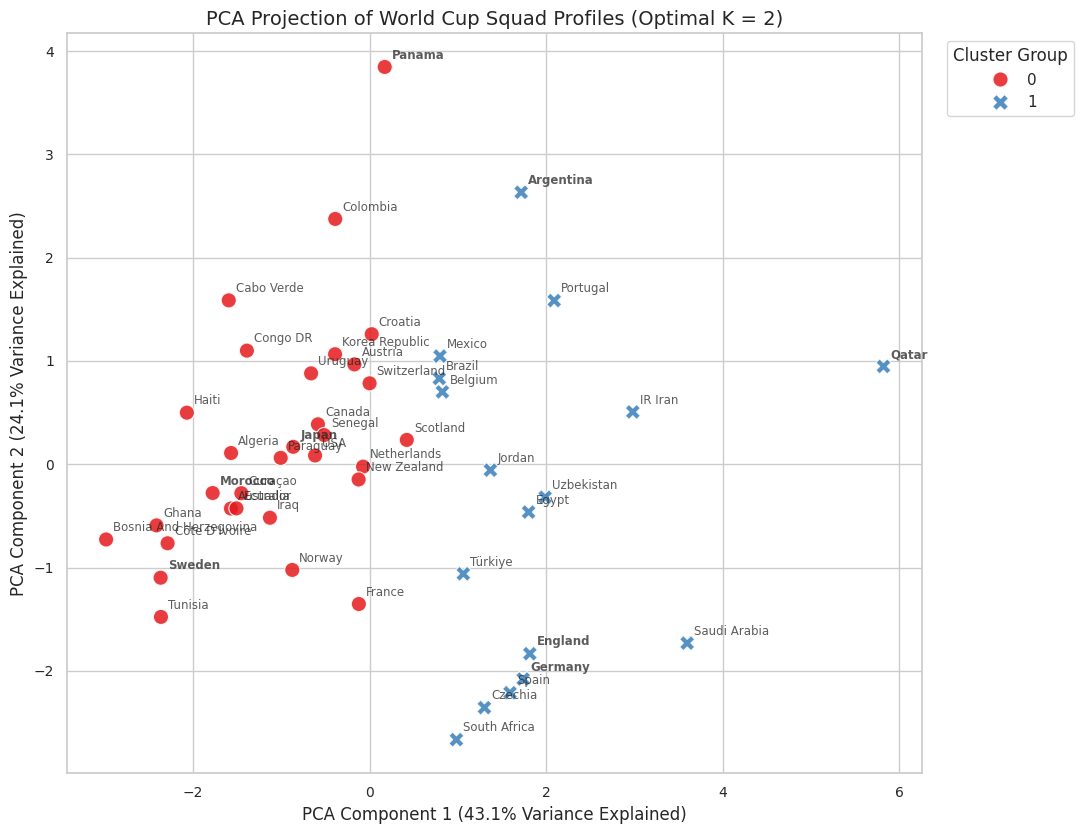

In [35]:
pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(scaled_features)

team_stats['PCA1'] = pca_features[:, 0]

team_stats['PCA2'] = pca_features[:, 1]

evr = pca.explained_variance_ratio_



plt.figure(figsize=(11, 8.5))

sns.scatterplot(

    data=team_stats,

    x='PCA1',

    y='PCA2',

    hue='Cluster',

    palette='Set1',

    style='Cluster',

    s=120,

    alpha=0.85

)



# Annotate all team points

for _, row in team_stats.iterrows():

    plt.annotate(

        row['Team'], 

        (row['PCA1'] + 0.08, row['PCA2'] + 0.08),

        fontsize=8.5, 

        alpha=0.75,

        weight='semibold' if row['Team'] in label_teams else 'normal'

    )



plt.title(f'PCA Projection of World Cup Squad Profiles (Optimal K = {optimal_k})')

plt.xlabel(f'PCA Component 1 ({evr[0]*100:.1f}% Variance Explained)')

plt.ylabel(f'PCA Component 2 ({evr[1]*100:.1f}% Variance Explained)')

plt.legend(title='Cluster Group', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

plt.show()


## Quantitative Characterization of Squad Profiles



We extract the statistical center of each cluster. This table lists the mean values of the 7 features for each squad archetype, allowing us to interpret their defining features.


In [36]:
cluster_means = team_stats.groupby('Cluster')[features].mean()

print("Mean values of features for each cluster:")

display(cluster_means.round(3))



print("\n--- Team Distribution Across Clusters ---\n")

for c in sorted(team_stats['Cluster'].unique()):

    cluster_teams = team_stats[team_stats['Cluster'] == c]['Team'].tolist()

    print(f"Cluster {c} ({len(cluster_teams)} teams):")

    print(", ".join(cluster_teams))

    print()


Mean values of features for each cluster:


,Average_Age,Average_Height,Average_Caps,Average_Goals,Domestic_Reliance,Club_Synergy,League_Diversity
Cluster,,,,,,,
0,27.735,183.161,32.597,3.960,0.120,0.129,11.097
1,28.235,182.045,38.385,5.457,0.561,0.449,6.235



--- Team Distribution Across Clusters ---

Cluster 0 (31 teams):
Algeria, Australia, Austria, Bosnia And Herzegovina, Cabo Verde, Canada, Colombia, Congo DR, Croatia, Curaçao, Côte D'Ivoire, Ecuador, France, Ghana, Haiti, Iraq, Japan, Korea Republic, Morocco, Netherlands, New Zealand, Norway, Panama, Paraguay, Scotland, Senegal, Sweden, Switzerland, Tunisia, USA, Uruguay

Cluster 1 (17 teams):
Argentina, Belgium, Brazil, Czechia, Egypt, England, Germany, IR Iran, Jordan, Mexico, Portugal, Qatar, Saudi Arabia, South Africa, Spain, Türkiye, Uzbekistan



## Concluding Sports Analytics Takeaways



Our data-driven segmentation shows that World Cup squad structures fall into distinct organizational patterns. Some squads are highly integrated through shared club-level experience, whereas others rely on globally dispersed talent pools, suggesting different preparation requirements for the tournament.
